# EDA — Telco Customer Churn

Análise exploratória do dataset `blastchar/telco-customer-churn` consumindo os mesmos módulos usados no pipeline de produção (`churn.dataset.loader`, `churn.dataset.preprocessing`).

Objetivo: caracterizar volume, qualidade, distribuição e prontidão dos dados (data readiness) antes do treino.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from churn.dataset.loader import load_raw_dataset
from churn.dataset.preprocessing import CATEGORICAL_FEATURES, NUMERIC_FEATURES, split_features_target

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 1. Volume e estrutura

In [2]:
df = load_raw_dataset()
print(f"Linhas:    {df.shape[0]:,}")
print(f"Colunas:   {df.shape[1]}")
print(f"Memoria:   {df.memory_usage(deep=True).sum() / 1024:.1f} KiB")
df.head()

Linhas:    7,043
Colunas:   21
Memoria:   7975.1 KiB


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Note dois pontos a serem corrigidos no pré-processamento:

- `TotalCharges` chega como `object` em vez de numérico — há linhas com strings em branco.
- `SeniorCitizen` é `int 0/1` enquanto outros booleanos são `Yes/No`.

## 2. Qualidade dos dados

In [4]:
missing = df.isnull().sum()
print("Nenhum NaN explicito" if not missing.any() else missing[missing > 0])

Nenhum NaN explicito


In [5]:
# TotalCharges como string vazia conta como missing implicito
total_charges_empty = (df["TotalCharges"].astype(str).str.strip() == "").sum()
print(f"Linhas com TotalCharges em branco: {total_charges_empty}")

Linhas com TotalCharges em branco: 11


In [6]:
dups = df.duplicated().sum()
print(f"Linhas duplicadas: {dups}")
print(f"customerIDs unicos: {df['customerID'].nunique():,} (vs {len(df):,} linhas)")

Linhas duplicadas: 0
customerIDs unicos: 7,043 (vs 7,043 linhas)


## 3. Distribuição do target

In [7]:
target = df["Churn"].value_counts()
target_pct = df["Churn"].value_counts(normalize=True) * 100
pd.DataFrame({"count": target, "pct": target_pct.round(2)})

,count,pct
Churn,,
No,5174,73.46
Yes,1869,26.54


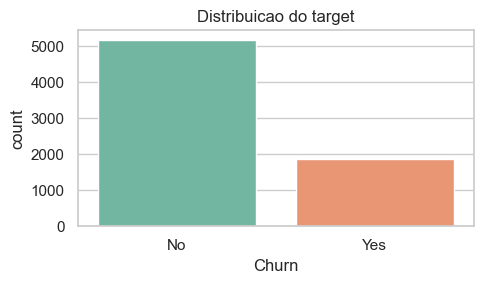

In [8]:
fig, ax = plt.subplots(figsize=(5, 3))
sns.countplot(data=df, x="Churn", order=["No", "Yes"], hue="Churn", palette="Set2", legend=False, ax=ax)
ax.set_title("Distribuicao do target")
plt.tight_layout()
plt.show()

Dataset desbalanceado mas longe de raro: 26,5% de churn. "Sempre prever No" gera accuracy de 73,5% e F1 zero — por isso usamos ROC AUC, PR AUC, recall e F1 em paralelo, nunca accuracy isoladamente.

## 4. Features numéricas

In [9]:
X, y = split_features_target(df)
X = X.copy()
X["TotalCharges"] = pd.to_numeric(X["TotalCharges"], errors="coerce")
X[NUMERIC_FEATURES].describe()

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
count,7043.000000,7043.000000,7032.000000,7043.000000
mean,32.371149,64.761692,2283.300441,0.162147
std,24.559481,30.090047,2266.771362,0.368612
min,0.000000,18.250000,18.800000,0.000000
25%,9.000000,35.500000,401.450000,0.000000
50%,29.000000,70.350000,1397.475000,0.000000
75%,55.000000,89.850000,3794.737500,0.000000
max,72.000000,118.750000,8684.800000,1.000000


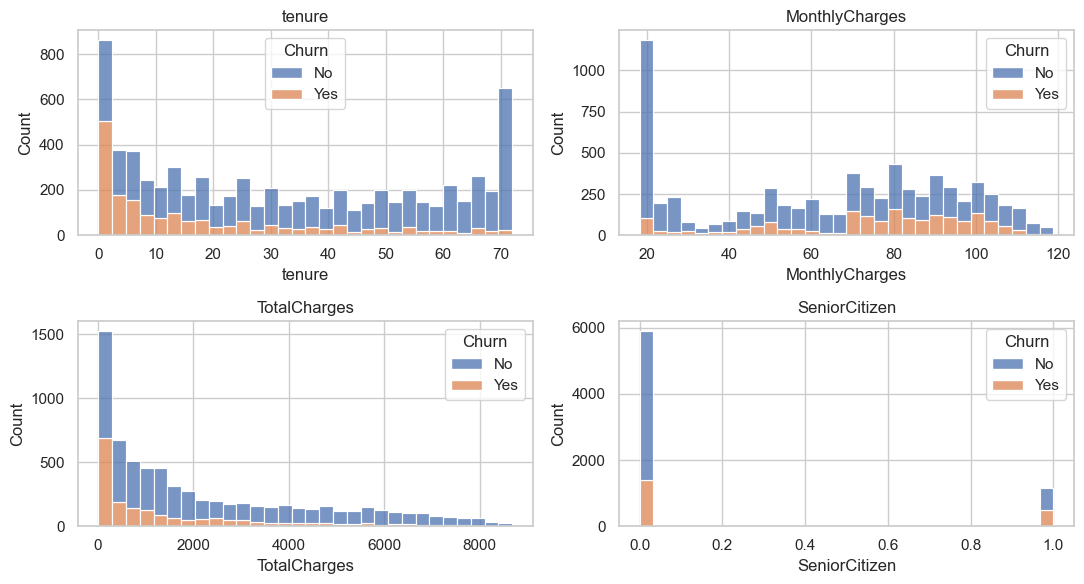

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
plot_df = X.assign(Churn=df["Churn"].values)
for ax, col in zip(axes.flat, NUMERIC_FEATURES, strict=False):
    sns.histplot(data=plot_df, x=col, hue="Churn", multiple="stack", bins=30, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Observações:

- **`tenure`**: distribuição bimodal — muitos clientes muito novos (alto risco) e muitos clientes antigos (baixo risco).
- **`MonthlyCharges`**: clientes pagando entre US$70 e US$100 concentram boa parte dos churns (geralmente fibra óptica).
- **`TotalCharges`**: derivado de `tenure × MonthlyCharges` — fortemente correlacionado com `tenure`.
- **`SeniorCitizen`**: minoria do dataset, mas com taxa de churn proporcionalmente maior.

## 5. Features categóricas — taxa de churn por categoria

In [11]:
def churn_rate_by(col):
    return (
        df.assign(Churn_=(df["Churn"] == "Yes").astype(int))
        .groupby(col)["Churn_"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "churn_rate"})
        .sort_values("churn_rate", ascending=False)
    )


for col in ["Contract", "InternetService", "PaymentMethod", "OnlineSecurity", "TechSupport"]:
    print(f"--- {col} ---")
    print(churn_rate_by(col))
    print()

--- Contract ---
                churn_rate  count
Contract                         
Month-to-month    0.427097   3875
One year          0.112695   1473
Two year          0.028319   1695

--- InternetService ---
                 churn_rate  count
InternetService                   
Fiber optic        0.418928   3096
DSL                0.189591   2421
No                 0.074050   1526

--- PaymentMethod ---
                           churn_rate  count
PaymentMethod                               
Electronic check             0.452854   2365
Mailed check                 0.191067   1612
Bank transfer (automatic)    0.167098   1544
Credit card (automatic)      0.152431   1522

--- OnlineSecurity ---
                     churn_rate  count
OnlineSecurity                        
No                     0.417667   3498
Yes                    0.146112   2019
No internet service    0.074050   1526

--- TechSupport ---
                     churn_rate  count
TechSupport                           
No

Insights diretos:

- **`Contract = Month-to-month`**: ~43% de churn vs ~3% para 2-year — feature mais informativa do dataset.
- **`InternetService = Fiber optic`**: ~42% de churn vs ~7% para clientes sem internet.
- **`PaymentMethod = Electronic check`**: ~45% de churn — possível proxy de perfil financeiro.
- **`OnlineSecurity` e `TechSupport` ausentes**: aumentam churn em ~20 pp.

Estes padrões alinham com estudos publicados sobre o mesmo dataset.

## 6. Correlações entre features numéricas

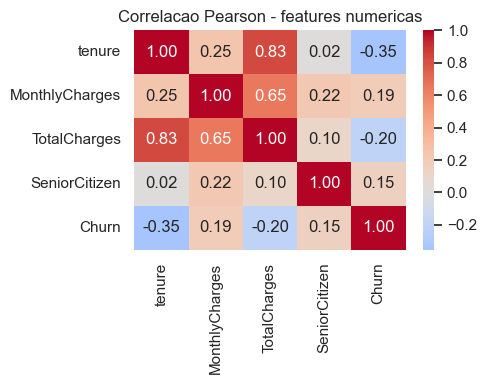

In [12]:
numeric_with_target = X[NUMERIC_FEATURES].assign(Churn=y)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(numeric_with_target.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlacao Pearson - features numericas")
plt.tight_layout()
plt.show()

`tenure` e `Churn` têm correlação negativa marcante (~-0,35) — clientes de longo prazo são fiéis. `MonthlyCharges` correlaciona positivamente com `Churn` (~0,19).

## 7. Data readiness — checklist

| Aspecto | Estado | Ação no pipeline |
|---|---|---|
| Volume suficiente | 7.043 linhas — adequado para tabular | sem ação |
| Duplicatas | 0 | sem ação |
| Missing explícito | 0 | sem ação |
| Missing implícito (`TotalCharges` em branco) | 11 linhas | coerção + imputer mediana no `FeatureEngineer` |
| Inconsistência de tipo (`SeniorCitizen`) | sim | tratado pelo `OneHotEncoder` (aceita int e str) |
| Identificador a remover | `customerID` | dropado em `split_features_target` |
| Target categórico | `Yes`/`No` | mapeado para 1/0 |
| Desbalanceamento | 73/27 | `pos_weight` no MLP, `class_weight=balanced` nos baselines, threshold tuning |
| Categorias de baixa cardinalidade | sim, todas one-hot encodáveis | `OneHotEncoder(handle_unknown="ignore")` |

**Conclusão**: dataset está pronto para treino com o pipeline em `churn.dataset.preprocessing`.